# Solución Problemset 7: Astrobiología — Origen y Evolución de la Vida

**Autor:** Daniel Soto  
**Curso:** Problemas de Astronomía \#7  
**Kernel:** Wolfram Language 12.3  

---

Este notebook presenta soluciones extensas, claras y ordenadas a los tres problemas del **Problemset 7**, que tratan sobre el *origen de la vida*, las *formas de vida más pequeñas conocidas* y la *evolución de nucleótidos y genes* a lo largo de la historia biológica.

---

## Problema 1: El Origen de la Vida

La vida en la Tierra ha evolucionado a través de diversas eras geológicas desde la formación del planeta hace **4.6 Gy** (miles de millones de años). Asumiendo un planeta similar a la Tierra, se calculan los siguientes **porcentajes de tiempo**, expresados relativamente a la edad total del planeta:

1. Porcentaje de tiempo en que el planeta tiene **vida de cualquier tipo**.  
2. Porcentaje de tiempo en que **solo existe vida bacteriana** (unicelular).  
3. Porcentaje de tiempo en que las formas de vida son **más complejas que las bacterias**.  
4. Porcentaje de tiempo en que existieron formas de vida **similares a los mamíferos**.  
5. Porcentaje de tiempo en que las formas de vida son tan inteligentes como los **humanos modernos**.

### Eventos clave extraídos del enunciado

| Evento | Tiempo atrás |
|--------|-------------|
| Primera vida unicelular (bacterias) | **3.8 Gy** |
| Primeros protistas (primera vida compleja unicelular) | **1.8 Gy** |
| Eucariotas multicelulares | **1.0 Gy** |
| Fin de dinosaurios — surgimiento de mamíferos | **65 My** |
| Humanos modernos | **50 000 años** |


RESULTADOS — PROBLEMA 1: PORCENTAJES DE TIEMPO

#   Pregunta                          Duración     Porcentaje (%)

1   Vida de cualquier tipo            3.8 Gy       82.6087

2   Solo vida bacteriana              2. Gy        43.4783

3   Vida más compleja que bacterias   1.8 Gy       39.1304

4   Formas de vida tipo mamífero      65.0 My      1.41304

5   Humanos modernos                  50000 años   0.00109
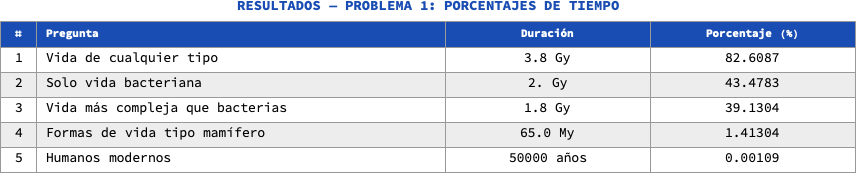

In [1]:
Clear["Global`*"]

(* ═══════════════════════════════════════════════════════════ *)
(*  PROBLEMA 1 — DATOS Y CÁLCULO DE PORCENTAJES               *)
(* ═══════════════════════════════════════════════════════════ *)

(* Edad del planeta similar a la Tierra *)
edadTierra         = 4.6  * 10^9;   (* años *)

(* Eventos clave: tiempo atrás en años *)
aparicionVida      = 3.8  * 10^9;   (* Primera vida unicelular            *)
aparicionProtistas = 1.8  * 10^9;   (* Protistas: vida más compleja       *)
aparicionMamiferos = 65   * 10^6;   (* Surgimiento de mamíferos           *)
aparicionHumanos   = 50000;          (* Humanos modernos                   *)

(* ─── Duraciones de cada período relevante ─── *)
durConVida       = aparicionVida;
durSoloBacterias = aparicionVida - aparicionProtistas;
durMasCompleja   = aparicionProtistas;
durMamiferos     = aparicionMamiferos;
durHumanos       = aparicionHumanos;

(* ─── Porcentajes respecto a la edad total ─── *)
p1 = N[durConVida       / edadTierra * 100, 5];
p2 = N[durSoloBacterias / edadTierra * 100, 5];
p3 = N[durMasCompleja   / edadTierra * 100, 5];
p4 = N[durMamiferos     / edadTierra * 100, 5];
p5 = N[durHumanos       / edadTierra * 100, 7];

(* ─── Tabla de resultados ─── *)
Grid[{
  {Style["RESULTADOS — PROBLEMA 1: PORCENTAJES DE TIEMPO", Bold, 14, RGBColor[0.1,0.3,0.7]]},
  {Grid[{
    {Style["#",Bold,11,White],Style["Pregunta",Bold,11,White],
     Style["Duración",Bold,11,White],Style["Porcentaje (%)",Bold,11,White]},
    {"1","Vida de cualquier tipo",
     ToString[N[durConVida/10^9,3]]<>" Gy",ToString[p1]},
    {"2","Solo vida bacteriana",
     ToString[N[durSoloBacterias/10^9,3]]<>" Gy",ToString[p2]},
    {"3","Vida más compleja que bacterias",
     ToString[N[durMasCompleja/10^9,3]]<>" Gy",ToString[p3]},
    {"4","Formas de vida tipo mamífero",
     ToString[N[durMamiferos/10^6,3]]<>" My",ToString[p4]},
    {"5","Humanos modernos",
     ToString[durHumanos]<>" años",
     ToString[NumberForm[p5,{7,5}]]}
  },
  Frame->All, FrameStyle->GrayLevel[0.6],
  Background->{None,{RGBColor[0.1,0.3,0.7],{White,GrayLevel[0.93]}}},
  Spacings->{1.5, 0.9},
  Alignment->{{Center,Left,Center,Center}},
  ItemSize->{{1,Scaled[0.42],Scaled[0.2],Scaled[0.2]}}]}},
 Spacings->{0,0.5}, Frame->None]


-Graphics-
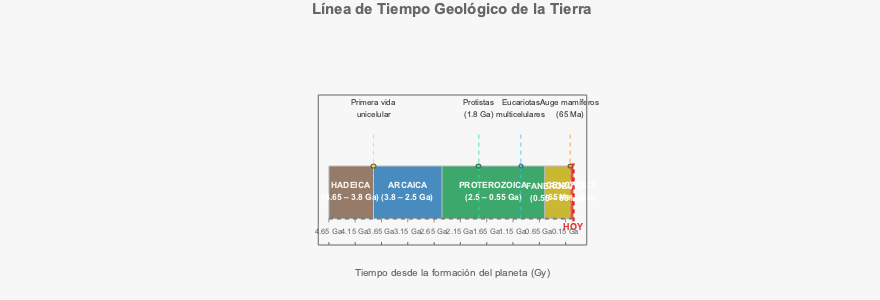

In [26]:
(* ─── GRÁFICA 1A: LÍNEA DE TIEMPO GEOLÓGICO ─── *)
(* Eje x: tiempo desde la FORMACIÓN de la Tierra en Gy         *)
(* x = 0 → formación (4.65 Ga)   |   x = 4.65 → hoy           *)

colEras = {
  RGBColor[0.55, 0.44, 0.36],   (* Hadeica      — marrón arcilloso *)
  RGBColor[0.22, 0.51, 0.73],   (* Arcaica      — azul acero       *)
  RGBColor[0.17, 0.63, 0.37],   (* Proterozoica — verde selva      *)
  RGBColor[0.78, 0.70, 0.13],   (* Fanerozóica  — dorado           *)
  RGBColor[0.88, 0.31, 0.14]    (* Cenozoica    — rojo ladrillo    *)
};

(* {x_ini, x_fin, nombre} con x = 4.65 − tiempo_atras_Gy *)
erasDatos = {
  {0,      0.85,   "HADEICA\n(4.65 – 3.8 Ga)"},
  {0.85,   2.15,   "ARCAICA\n(3.8 – 2.5 Ga)"},
  {2.15,   4.10,   "PROTEROZOICA\n(2.5 – 0.55 Ga)"},
  {4.10,   4.585,  "FANEROZÓICA\n(0.55 – 65 Ma)"},
  {4.585,  4.65,   "CENOZOICA\n(65 Ma – hoy)"}
};

bloques = MapIndexed[Function[{era, idx},
  {Opacity[0.92], colEras[[idx[[1]]]],
   EdgeForm[Directive[Thin, GrayLevel[0.75]]],
   Rectangle[{era[[1]], 0.0}, {era[[2]], 1.0}]}], erasDatos];

etiqEras = MapIndexed[Function[{era, idx},
  Text[Style[era[[3]], Bold, 8.5, White],
       {(era[[1]] + era[[2]])/2, 0.5}]], erasDatos];

(* Eventos clave: {x_pos, etiqueta, color} *)
eventos = {
  {0.85,  "Primera vida\nunicelular",   RGBColor[1.00, 0.85, 0.10]},
  {2.85,  "Protistas\n(1.8 Ga)",        RGBColor[0.15, 0.92, 0.55]},
  {3.65,  "Eucariotas\nmulticelulares", RGBColor[0.20, 0.78, 1.00]},
  {4.585, "Auge mamíferos\n(65 Ma)",    RGBColor[1.00, 0.55, 0.10]}
};

lineasEvt = Map[Function[evt,
  {Thickness[0.004], Opacity[0.85], evt[[3]], Dashed,
   Line[{{evt[[1]], 0.0}, {evt[[1]], 1.65}}]}], eventos];

puntosEvt = Map[Function[evt,
  {evt[[3]], EdgeForm[{Thin, GrayLevel[0.3]}],
   Disk[{evt[[1]], 1.0}, 0.046]}], eventos];

textosEvt = Map[Function[evt,
  Text[Style[evt[[2]], 8, GrayLevel[0.1]],
       {evt[[1]], 1.85}, {0, -1}]], eventos];

marcaHoy = {
  {AbsoluteThickness[2.5], RGBColor[0.85, 0.1, 0.1],
   Line[{{4.65, -0.05}, {4.65, 1.05}}]},
  Text[Style["HOY", Bold, 9, RGBColor[0.85, 0.1, 0.1]], {4.65, -0.18}]
};

(* Marcas de tiempo en eje x *)
marcasX = Table[
  {AbsoluteThickness[1], GrayLevel[0.5],
   Line[{{t, -0.07}, {t, 0}}]},
  {t, 0, 4.5, 0.5}];

etiqX = Table[
  Text[Style[ToString[NumberForm[N[4.65-t,3],{4,2}]]<>" Ga", 7.5, GrayLevel[0.35]],
       {t, -0.26}],
  {t, 0, 4.65, 0.5}];

Graphics[
  Flatten[{
    {GrayLevel[0.97], Rectangle[{-0.15, -0.42}, {4.85, 2.30}]},
    bloques, etiqEras,
    lineasEvt, puntosEvt, textosEvt,
    marcaHoy, marcasX, etiqX,
    {GrayLevel[0.45], AbsoluteThickness[1.8],
     Line[{{0, 0}, {4.65, 0}}]}
  }],
  PlotRange     -> {{-0.2, 4.9}, {-0.5, 2.35}},
  PlotLabel     -> Style["Línea de Tiempo Geológico de la Tierra", Bold, 15],
  FrameLabel    -> {{None,None},{Style["Tiempo desde la formación del planeta (Gy)",10],None}},
  Frame         -> True,
  FrameTicks    -> {{{},{  }},{Table[{t,""},{t,0,4.65,0.5}],{}}},
  Background    -> GrayLevel[0.97],
  ImageSize     -> {880, 300},
  ImagePadding  -> {{50, 25}, {55, 75}}]


-Graphics-
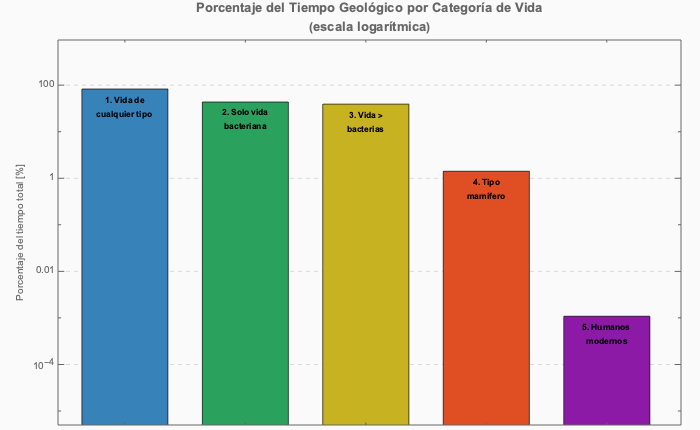

In [44]:
(* ─── GRÁFICA 1B: DIAGRAMA DE BARRAS (escala logarítmica) ─── *)
(* Los valores abarcan ~8 órdenes de magnitud, por lo que se   *)
(* usa escala log para visualizar todas las categorías.        *)

labels = {
  "1. Vida de\ncualquier tipo",
  "2. Solo vida\nbacteriana",
  "3. Vida >\nbacterias",
  "4. Tipo\nmamífero",
  "5. Humanos\nmodernos"
};
valores = {p1, p2, p3, p4, p5};

coloresBarra = {
  RGBColor[0.22, 0.51, 0.73],
  RGBColor[0.17, 0.63, 0.37],
  RGBColor[0.78, 0.70, 0.13],
  RGBColor[0.88, 0.31, 0.14],
  RGBColor[0.55, 0.10, 0.65]
};

anotaciones = MapThread[
  Callout[#1, Style[ToString[NumberForm[#2,{7,5}]]<>" %", 8, Bold, GrayLevel[0.2]],
         Above, Appearance -> None] &,
  {valores, valores}];

BarChart[anotaciones,
  ChartLabels   -> Placed[Map[Style[#, 8.5, Bold] &, labels], Below],
  ChartStyle    -> coloresBarra,
  ScalingFunctions -> "Log",
  PlotLabel     -> Style["Porcentaje del Tiempo Geológico por Categoría de Vida\n(escala logarítmica)", Bold, 13],
  FrameLabel    -> {{Style["Porcentaje del tiempo total [%]", 10], None}, {None, None}},
  Frame         -> True,
  FrameTicks    -> Automatic,
  GridLines     -> {None, Automatic},
  GridLinesStyle-> Directive[LightGray, Dashed],
  BarSpacing    -> 0.4,
  ImageSize     -> {700, 430},
  Background    -> GrayLevel[0.98],
  PlotRange     -> {5*10^-6, 200}]


---
## Problema 2: Las Formas de Vida Terrestres más Pequeñas

Se estudian los sistemas biológicos más pequeños conocidos. Para cada organismo/virus, se tienen sus diámetros (nm) y número de nucleótidos. El volumen se calcula asumiendo esfera perfecta.

### Datos del problema

| Nombre | Tamaño (nm) | Estado | Nucleótidos (miles) | Genes |
|--------|------------|--------|---------------------|-------|
| Porcine Circovirus   | 17   | No vivo | 1.8  | 2   |
| Hepatitis-B          | 42   | No vivo | 3.0  | 4   |
| Rous Sarcoma Virus   | 80   | No vivo | 3.5  | 3   |
| Lambda bacteriophage | 100  | No vivo | 48   | 30  |
| T4 bacteriophage     | 150  | No vivo | 169  | 160 |
| Mycoplasma Gen.      | 250  | **Vivo**| 582  | 521 |
| Nanoarchaeum Equit.  | 400  | **Vivo**| 491  | 590 |
| Escherichia Coli     | 2000 | **Vivo**| 4000 | 3000|

**Preguntas:**
1. Graficar $\log_{10}(V)$ vs $\log_{10}(N)$ para cada sistema.
2. ¿Una forma de vida con ~1 000 nucleótidos sería viva o no viva?
3. ¿Cuántos nucleótidos tendría un organismo con $V = 10^{12}\ \text{nm}^3$?
4. ¿Cuántos bacteriófagos T4 caben en una *E. coli*?


Nombre                 d (nm)   V (nm³)      log₁₀V   N (×10³)   log₁₀N   Estado

Porcine Circovirus     17       2572.44      3.4103   1.8        0.2553   No vivo

Hepatitis-B            42       38792.40     4.5887   3.         0.4771   No vivo

Rous sarcoma Virus     80       268083.00    5.4283   3.5        0.5441   No vivo

Lambda bacteriophage   100      523599.00    5.7190   48         1.6812   No vivo

                                         6
T4 bacteriophage       150      1.77 × 10    6.2473   169        2.2279   No vivo

                                         6
Mycoplasma Gen.        250      8.18 × 10    6.9128   582        2.7649   Vivo

                                         7
Nanoarchaeum Equit.    400      3.35 × 10    7.5252   491        2.6911   Vivo

                                         9
Escherichia Coli       2000     4.19 × 10    9.6221   4000       3.6021   Vivo
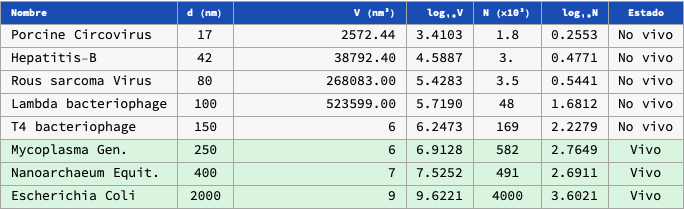

In [52]:
Clear["Global`*"]

(* ═══════════════════════════════════════════════════════════ *)
(*  PROBLEMA 2 — IMPORTACIÓN DE DATOS Y CÁLCULO DE VOLÚMENES  *)
(* ═══════════════════════════════════════════════════════════ *)

ruta = FileNameJoin[{Directory[], "BiologicalSystems.dat"}];
datosRaw = Import[ruta, "Table"];

(* Columnas: nombre, diámetro (nm), nucleótidos (miles), genes *)
nombres       = datosRaw[[All, 1]];
diametros     = datosRaw[[All, 2]];   (* nm *)
nucleotidosK  = datosRaw[[All, 3]];   (* en miles *)
genes         = datosRaw[[All, 4]];

(* Estado (vivo / no vivo) — primeros 5 no vivos, últimos 3 vivos *)
estados = {"No vivo","No vivo","No vivo","No vivo","No vivo","Vivo","Vivo","Vivo"};
n = Length[nombres];

(* ─── Volumen de cada organismo (esfera perfecta) ─── *)
(* V = (4/3) π (d/2)^3  con d en nm → V en nm³          *)
volumenes = Table[N[(4/3) Pi (diametros[[i]]/2)^3, 8], {i, n}];

(* ─── Logaritmos en base 10 ─── *)
logV = N[Log10[volumenes], 6];
logN = N[Log10[nucleotidosK], 6];

(* ─── Tabla de resultados ─── *)
Grid[
  Prepend[
    Table[{nombres[[i]], diametros[[i]], ToString[NumberForm[volumenes[[i]],{6,2}]],
           ToString[NumberForm[logV[[i]],{6,4}]],
           nucleotidosK[[i]], ToString[NumberForm[logN[[i]],{6,4}]],
           estados[[i]]},
          {i, n}],
    {Style["Nombre",Bold,10,White], Style["d (nm)",Bold,10,White],
     Style["V (nm³)",Bold,10,White], Style["log₁₀V",Bold,10,White],
     Style["N (×10³)",Bold,10,White], Style["log₁₀N",Bold,10,White],
     Style["Estado",Bold,10,White]}],
  Frame -> All, FrameStyle -> GrayLevel[0.65],
  Background -> {None, Prepend[
    Table[If[estados[[i]] == "Vivo", RGBColor[0.85,0.96,0.88], GrayLevel[0.97]], {i,n}],
    RGBColor[0.1,0.3,0.7]]},
  Alignment -> {{Left,Center,Right,Right,Center,Right,Center}},
  Spacings -> {1.5, 0.8}]


-Graphics-
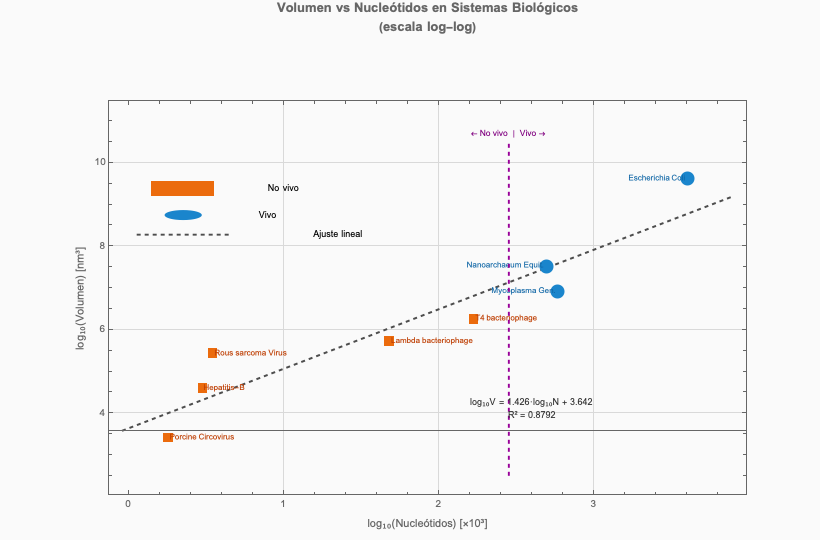

In [74]:
(* ─── GRÁFICA 2: LOG₁₀(V) vs LOG₁₀(N) con regresión lineal ─── *)

(* Índices: no vivos [1..5], vivos [6..8] *)
puntoNV = Table[{logN[[i]], logV[[i]]}, {i, 1, 5}];   (* No vivos *)
puntoVV = Table[{logN[[i]], logV[[i]]}, {i, 6, 8}];   (* Vivos    *)

(* Ajuste lineal global *)
puntosTodos = Table[{logN[[i]], logV[[i]]}, {i, n}];
modelo = LinearModelFit[puntosTodos, {1, x}, x];
pendiente = modelo["BestFitParameters"][[2]];
intercepto = modelo["BestFitParameters"][[1]];
r2 = modelo["RSquared"];

xMin = Min[logN] - 0.3;
xMax = Max[logN] + 0.3;

(* Función de ajuste *)
fitLine = Plot[modelo[x], {x, xMin, xMax},
  PlotStyle -> {Directive[RGBColor[0.3, 0.3, 0.3], Thick, Dashed]},
  DisplayFunction -> Identity];

(* Dispersión — No vivos (naranja ■) *)
scatterNV = ListPlot[puntoNV,
  PlotStyle -> Directive[RGBColor[0.92, 0.42, 0.05], PointSize[0.022]],
  PlotMarkers -> {Graphics[{RGBColor[0.92,0.42,0.05], Rectangle[{-1,-1},{1,1}]}], 0.025},
  DisplayFunction -> Identity];

(* Dispersión — Vivos (azul ●) *)
scatterVV = ListPlot[puntoVV,
  PlotStyle -> Directive[RGBColor[0.10, 0.52, 0.80], PointSize[0.022]],
  DisplayFunction -> Identity];

(* Etiquetas de cada punto *)
etiquetasPuntos = Graphics[
  Table[
    Text[
      Style[nombres[[i]], 8, If[estados[[i]]=="Vivo",
        RGBColor[0.06,0.40,0.65], RGBColor[0.75,0.25,0.02]]],
      {logN[[i]], logV[[i]]},
      If[logN[[i]] > 2.5, {1.05, 0}, {-1.05, 0}]
    ], {i, n}]];

(* Línea vertical en la frontera vivo/no-vivo *)
(* Frontera: entre log₁₀(169)=2.228 (T4, no vivo) y log₁₀(491)=2.691 (Nano, vivo) *)
xFrontera = 2.45;
lineaFront = Graphics[{
  Directive[RGBColor[0.6, 0.0, 0.6], Thickness[0.003], Dashed],
  Line[{{xFrontera, 2.5}, {xFrontera, 10.5}}],
  Text[Style["← No vivo  |  Vivo →", 8.5, RGBColor[0.5,0.0,0.5]],
       {xFrontera, 10.7}]
}];

(* Leyenda manual *)
leyenda = Graphics[{
  {RGBColor[0.92,0.42,0.05], Rectangle[{0.15,9.2},{0.55,9.55}]},
  Text[Style["No vivo", 9], {1.0, 9.38}],
  {RGBColor[0.10,0.52,0.80], Disk[{0.35,8.75},0.12]},
  Text[Style["Vivo", 9], {0.9, 8.75}],
  {Directive[GrayLevel[0.3],Dashed,Thickness[0.003]],
   Line[{{0.05,8.28},{0.65,8.28}}]},
  Text[Style["Ajuste lineal", 9], {1.35, 8.28}]
}];

eqLabel = Graphics[Text[
  Style["log₁₀V = "<>ToString[NumberForm[pendiente,{5,3}]]<>"·log₁₀N + "
        <>ToString[NumberForm[intercepto,{5,3}]]
        <>"\nR² = "<>ToString[NumberForm[r2,{5,4}]], 9,
    RGBColor[0.2,0.2,0.2]],
  {2.6, 4.1}]];

Show[fitLine, scatterNV, scatterVV, etiquetasPuntos, lineaFront, leyenda, eqLabel,
  Frame        -> True,
  FrameLabel   -> {{Style["log₁₀(Volumen) [nm³]",11],None},
                   {Style["log₁₀(Nucleótidos) [×10³]",11],None}},
  PlotLabel    -> Style["Volumen vs Nucleótidos en Sistemas Biológicos\n(escala log-log)",Bold,13],
  PlotRange    -> {{xMin, xMax}, {2.5, 11.0}},
  GridLines    -> Automatic,
  GridLinesStyle -> Directive[LightGray, Thin],
  ImageSize    -> {820, 540},
  Background   -> GrayLevel[0.98],
  ImagePadding -> {{65, 30}, {45, 65}}]


### Respuestas a las preguntas 2, 3 y 4

Se usa la ecuación de regresión obtenida del ajuste:
$$\log_{10}V = s \cdot \log_{10}N + b$$
donde $s$ es la pendiente y $b$ el intercepto.


In [102]:
(* ═══════════════════════════════════════════════════════════ *)
(*  PREGUNTA 2: Organismo con ~1 000 nucleótidos               *)
(* ═══════════════════════════════════════════════════════════ *)

N1000 = 1.0;   (* 1 000 nucleótidos = 1 (en miles) *)
logN1000 = Log10[N1000];   (* = 0 *)
logV1000 = modelo[logN1000];
V1000 = 10^logV1000;

Print[Style["Pregunta 2: Organismo con ~1 000 nucleótidos", Bold, 13,
      RGBColor[0.1,0.3,0.7]]];
Print["  log₁₀(N) = ", logN1000];
Print["  log₁₀(V) predicho = ", NumberForm[logV1000, {6,3}]];
Print["  Volumen estimado  = ", NumberForm[V1000, {5,2}], " nm³"];
Print["  Diámetro estimado = ", NumberForm[2*(3*V1000/(4*Pi))^(1/3), {5,2}], " nm"];
Print[];
Print["  Clasificación plausible: ", Style["NO VIVO", Bold, Red]];
Print["  Justificación: con solo 1 000 nucleótidos (log₁₀N = 0) el punto cae"];
Print["  muy por debajo de la frontera vivo/no-vivo identificada en log₁₀N ≈ 2.45."];
Print["  Todos los sistemas con nucleótidos similares o menores (Porcine Circovirus,"];
Print["  Hepatitis-B) son clasificados como no vivos."];


Pregunta 2: Organismo con ~1 000 nucleo'tidos
  log\:2081\:2080(N) = 0.
  log\:2081\:2080(V) predicho = 3.642
  Volumen estimado  = 4385.30 nm\263
  Dia'metro estimado = 20.31 nm

  Clasificacio'n plausible: NO VIVO
  Justificacio'n: con solo 1 000 nucleo'tidos (log\:2081\:2080N = 0) el punto\
 
>   cae
  muy por debajo de la frontera vivo/no-vivo identificada en log\:2081\:2080N\
 
>   ~~ 2.45.
  Todos los sistemas con nucleo'tidos similares o menores (Porcine\
 
>   Circovirus,
  Hepatitis-B) son clasificados como no vivos.


In [120]:
(* ═══════════════════════════════════════════════════════════ *)
(*  PREGUNTA 3: Organismo con V = 10^12 nm³                    *)
(* ═══════════════════════════════════════════════════════════ *)

Vtarget = 10^12;    (* nm³ *)
logVtarget = 12;
(* Despejar log₁₀N de la ecuación de ajuste *)
logNtarget = (logVtarget - intercepto) / pendiente;
Ntarget = 10^logNtarget;   (* en miles *)
Ntarget_absoluto = Ntarget * 1000;

Print[Style["Pregunta 3: Organismo con V = 10¹² nm³", Bold, 13,
      RGBColor[0.1,0.3,0.7]]];
Print["  log₁₀(V) = ", logVtarget];
Print["  log₁₀(N) = (", logVtarget, " - ", NumberForm[intercepto,{5,3}],
      ") / ", NumberForm[pendiente,{5,3}], " = ",
      NumberForm[logNtarget,{6,4}]];
Print["  N estimado = 10^", NumberForm[logNtarget,{6,4}], " × 10³ nucleótidos"];
Print["  N estimado = ", NumberForm[Ntarget,{6,2}], " miles de nucleótidos"];
Print["  N estimado = ", NumberForm[Ntarget_absoluto,{6,2}], " nucleótidos"];
Print[];
diamTarget = 2*(3*Vtarget/(4*Pi))^(1/3);
Print["  Diámetro correspondiente: ", NumberForm[diamTarget, {6,1}], " nm = ",
      NumberForm[diamTarget/1000, {5,2}], " μm"];
Print[];
Print["  Clasificación: dado que log₁₀N ≈ ", NumberForm[logNtarget,{5,3}],
      " > 2.45 (frontera), este organismo"];
Print["  sería clasificado como ", Style["VIVO", Bold, RGBColor[0.0,0.6,0.2]],
      " (nucleótidos comparables a E. coli o mayores)."];


Pregunta 3: Organismo con V = 10\271\262 nm\263
  log\:2081\:2080(V) = 12
  log\:2081\:2080(N) = (12 - 3.642) / 1.426 = 5.8593
  N estimado = 10^5.8593 x 10\263 nucleo'tidos
  N estimado = 723350.00 miles de nucleo'tidos
  N estimado = Ntarget_absoluto nucleo'tidos

                                    6  1/3          6  1/3
  Dia'metro correspondiente: 10000 (--)    nm = 10 (--)    \[Mu]m
                                    Pi              Pi

  Clasificacio'n: dado que log\:2081\:2080N ~~ 5.859
 
>    > 2.45 (frontera), este organismo
  seri'a clasificado como VIVO (nucleo'tidos comparables a E. coli o mayores).


In [141]:
(* ═══════════════════════════════════════════════════════════ *)
(*  PREGUNTA 4: Bacteriófagos T4 dentro de E. Coli             *)
(* ═══════════════════════════════════════════════════════════ *)

dT4   = 150;    (* nm — diámetro T4 *)
dEcoli = 2000;  (* nm — diámetro E. coli *)

VT4   = N[(4/3) Pi (dT4/2)^3,   8];
VEcoli = N[(4/3) Pi (dEcoli/2)^3, 8];

(* Factor de empaquetamiento esférico aleatorio ≈ 0.64 *)
fpack = 0.64;
nT4 = Floor[fpack * VEcoli / VT4];
nT4TheoreticalMax = Floor[VEcoli / VT4];

Print[Style["Pregunta 4: Bacteriófagos T4 en E. Coli", Bold, 13,
      RGBColor[0.1,0.3,0.7]]];
Print[];
Print["  Volumen de T4 (d=", dT4, " nm):   ", NumberForm[VT4, {6,3}], " nm³"];
Print["  Volumen de E.coli (d=", dEcoli, " nm): ", NumberForm[VEcoli, {6,3}], " nm³"];
Print[];
Print["  Cociente simple (V_coli / V_T4):"];
Print["    → ", nT4TheoreticalMax, " bacteriófagos T4"];
Print[];
Print["  Con factor de empaquetamiento esférico aleatorio (≈ 0.64):"];
Print["    → ", nT4, " bacteriófagos T4"];
Print[];
Print["  Nota: el número máximo aproximado es ", Style[ToString[nT4]<>" T4",Bold],
      " por bacteria E. Coli."];
Print["  (Valores experimentales reportados en la literatura: ~150–300 fagos por célula)"];


Pregunta 4: Bacterio'fagos T4 en E. Coli

                                        6
  Volumen de T4 (d=150 nm):   1.767 x 10  nm\263
                                           9
  Volumen de E.coli (d=2000 nm): 4.189 x 10  nm\263

  Cociente simple (V_coli / V_T4):
    -> 2370 bacterio'fagos T4

  Con factor de empaquetamiento esfe'rico aleatorio (~~ 0.64):
    -> 1517 bacterio'fagos T4

  Nota: el nu'mero ma'ximo aproximado es 1517 T4 por bacteria E. Coli.
  (Valores experimentales reportados en la literatura: ~150-300 fagos por\
 
>   ce'lula)


---
## Problema 3: La Evolución de los Nucleótidos y los Genes

Se analizan datos de secuenciación genómica de 10 organismos para estudiar cómo han evolucionado el número de genes y nucleótidos a lo largo del tiempo.

### Datos del problema

| Especie | Tipo | Edad (My) | Nucleótidos | Genes |
|---------|------|-----------|-------------|-------|
| Humano | Mamífero | 1 | 2 900 M | 23 000 |
| Ratón | Mamífero | 75 | 3 400 M | 23 000 |
| Arroz | Planta | 100 | 390 M | 28 300 |
| E. Coli | Bacteria | 150 | 4.6 M | 4 400 |
| Mosca de la fruta | Insecto | 250 | 122 M | 17 000 |
| Pez cebra | Peces | 300 | 1 200 M | 15 760 |
| Erizo de mar | Molusco | 300 | 814 M | 23 300 |
| Streptomyces Coel. | Bacteria | 450 | 6.7 M | 7 842 |
| Helicobacter Pylori | Bacteria | 150 | 1.7 M | 1 589 |
| Naegleria Gruberi | Ameba | 1 000 | 41 M | 15 727 |

**Nota:** "Edad" es el tiempo evolutivo de la especie (My atrás desde hoy). Especies más recientes (edad menor) son evolutivamente más avanzadas.

**Preguntas:**
1. Gráfica de genes (miles) vs tiempo (unidades de 100 My). ¿Cuál es la tasa de cambio?
2. Gráfica de nucleótidos (millones) vs tiempo (unidades de 100 My). ¿Cuál es la tasa de cambio?
3. Predicción para un planeta con la misma evolución pero con **7 Gy** de edad.


Datos importados correctamente: 10 organismos.



Especie                   Tipo       Edad (My)   Nucleótidos (M)   Genes

Humano                    Mamífero   1           2900.             23000

Raton                     Mamífero   75          3400.             23000

Arroz                     Planta     100         390.              28300

E. Coli                   Bacteria   150         4.6               4400

Pez cebra                 Peces      300         1200.             15760

Naegleria Gruberi         Ameba      1000        41.               15727

Streptomyces Coelicolor   Bacteria   450         6.7               7842

Mosca de la fruta         Insecto    250         122.              17000

Erizo de mar              Molusco    300         814.              23300

Helicobacter Pylori       Bacteria   150         1.7               1589
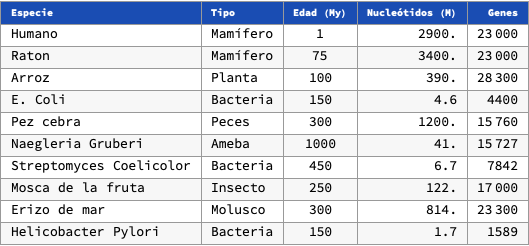

In [165]:
Clear["Global`*"]

(* ═══════════════════════════════════════════════════════════ *)
(*  PROBLEMA 3 — IMPORTACIÓN DE DATOS                         *)
(* ═══════════════════════════════════════════════════════════ *)

ruta3 = FileNameJoin[{Directory[], "NucleotidesEvolution.dat"}];
datos3 = Import[ruta3, "Table"];

(* Columnas: especie, edad (My), nucleótidos (M), genes *)
especies      = datos3[[All, 1]];
edadMy        = datos3[[All, 2]];           (* My *)
tiempoX       = datos3[[All, 2]] / 100.0;   (* unidades de 100 My *)
nucleotidosM  = N[datos3[[All, 3]]];        (* millones *)
genesK        = N[datos3[[All, 4]]] / 1000; (* miles de genes *)

(* Tipos de organismos para colorear *)
tipos = {"Mamífero","Mamífero","Planta","Bacteria","Peces",
         "Ameba","Bacteria","Insecto","Molusco","Bacteria"};

colTipos = <|
  "Mamífero"  -> RGBColor[0.15, 0.55, 0.85],
  "Planta"    -> RGBColor[0.15, 0.70, 0.30],
  "Bacteria"  -> RGBColor[0.88, 0.30, 0.14],
  "Peces"     -> RGBColor[0.85, 0.65, 0.10],
  "Insecto"   -> RGBColor[0.60, 0.20, 0.70],
  "Molusco"   -> RGBColor[0.20, 0.70, 0.70],
  "Ameba"     -> RGBColor[0.80, 0.50, 0.10]
|>;

n3 = Length[especies];
Print["Datos importados correctamente: ", n3, " organismos."];
Print[];
Grid[
  Prepend[
    Table[{especies[[i]], tipos[[i]], edadMy[[i]], nucleotidosM[[i]], Round[genesK[[i]]*1000]},
          {i, n3}],
    {Style["Especie",Bold,10,White], Style["Tipo",Bold,10,White],
     Style["Edad (My)",Bold,10,White], Style["Nucleótidos (M)",Bold,10,White],
     Style["Genes",Bold,10,White]}],
  Frame->All, FrameStyle->GrayLevel[0.6],
  Background->{None,Prepend[
    Table[If[EvenQ[i], GrayLevel[0.97], White], {i,n3}],
    RGBColor[0.1,0.3,0.7]]},
  Alignment->{{Left,Left,Center,Right,Right}},
  Spacings->{1.5,0.7}]


In [184]:
(* ─── GRÁFICA 3A: GENES (miles) vs TIEMPO (×100 My) ─── *)

(* Ajuste lineal usando humano y Naegleria como extremos *)
(* Humano: x≈0, y=23k; Naegleria: x=10, y=15.727k       *)
puntosGenes = Transpose[{tiempoX, genesK}];
modeloGenes = LinearModelFit[puntosGenes, {1, x}, x];
tasaGenes   = modeloGenes["BestFitParameters"][[2]];  (* k genes / (100My) *)
r2g         = modeloGenes["RSquared"];

xMinG = -0.3; xMaxG = 11;
fitGenes = Plot[modeloGenes[x], {x, xMinG, xMaxG},
  PlotStyle -> {Directive[GrayLevel[0.4], Thick, Dashed]},
  DisplayFunction -> Identity];

(* Agrupar por tipo *)
tiposUnicos = DeleteDuplicates[tipos];
puntosPorTipo = Table[
  {colTipos[t],
   Select[Transpose[{tiempoX, genesK, Range[n3]}],
          tipos[[#[[3]]]] == t &][[All, 1;;2]]},
  {t, tiposUnicos}];

scatters = Map[Function[{col, pts},
  ListPlot[pts,
    PlotStyle -> Directive[col, PointSize[0.022]],
    DisplayFunction -> Identity]
], puntosPorTipo, 1];

(* Etiquetas de especies *)
etiqGenes = Graphics[Table[
  Text[Style[especies[[i]], 7.5, colTipos[tipos[[i]]]],
       {tiempoX[[i]], genesK[[i]]},
       If[tiempoX[[i]] > 5, {1.05, 0}, {-1.1, 0.2}]],
  {i, n3}]];

(* Leyenda *)
leyendaG = Graphics[Flatten[{
  MapIndexed[Function[{t, idx},
    {colTipos[t], Disk[{0.3, 21.5 - (idx[[1]]-1)*1.3}, 0.15]},
    tiposUnicos],
  MapIndexed[Function[{t, idx},
    Text[Style[t, 8], {1.0, 21.5 - (idx[[1]]-1)*1.3}],
    tiposUnicos]
}]];

anotEq = Graphics[Text[
  Style["Ajuste lineal:\nGenesK = "<>ToString[NumberForm[tasaGenes,{6,3}]]
        <>" · t + "<>ToString[NumberForm[modeloGenes["BestFitParameters"][[1]],{6,3}]]
        <>"\nR² = "<>ToString[NumberForm[r2g,{5,4}]]
        <>"\nTasa ≈ "<>ToString[NumberForm[Abs[tasaGenes]*1000,{5,0}]]
        <>" genes / 100 My", 9, GrayLevel[0.25]],
  {7.5, 24.5}]];

Show[fitGenes, Sequence@@scatters, etiqGenes, leyendaG, anotEq,
  Frame       -> True,
  FrameLabel  -> {{Style["Número de Genes (× 10³)", 11], None},
                  {Style["Tiempo evolutivo (unidades de 100 My)", 11], None}},
  PlotLabel   -> Style["Evolución del Número de Genes en Organismos Terrestres", Bold, 13],
  PlotRange   -> {{xMinG, xMaxG}, {-1, 31}},
  GridLines   -> Automatic,
  GridLinesStyle -> Directive[LightGray, Thin],
  ImageSize   -> {820, 500},
  Background  -> GrayLevel[0.98],
  ImagePadding -> {{70, 30}, {45, 60}}]


Function::fpct: Too many parameters in {col, pts} to be filled from Function[{col, pts}, ListPlot[pts, PlotStyle -> Directive[col, PointSize[0.022]], DisplayFunction -> Identity]][{RGBColor[0.15, 0.55, 0.85], {{0.01, 23.}, {0.75, 23.}}}].

Function::fpct: Too many parameters in {col, pts} to be filled from Function[{col, pts}, ListPlot[pts, PlotStyle -> Directive[col, PointSize[0.022]], DisplayFunction -> Identity]][{RGBColor[0.15, 0.7, 0.3], {{1., 28.3}}}].

Function::fpct: Too many parameters in {col, pts} to be filled from Function[{col, pts}, ListPlot[pts, PlotStyle -> Directive[col, PointSize[0.022]], DisplayFunction -> Identity]][{RGBColor[0.88, 0.3, 0.14], {{1.5, 4.4}, {4.5, 7.842}, {1.5, 1.589}}}].

General::stop: Further output of Function::fpct will be suppressed during this calculation.

ToExpression::sntx: Invalid syntax in or before "                                                                                                                                                                                                                                                 ^".


$Failed

In [200]:
(* Resultados de la tasa de cambio de genes *)
Print[Style["Tasa de cambio de genes (Pregunta 1):", Bold, 13, RGBColor[0.1,0.3,0.7]]];
Print[];
Print["  Ajuste lineal: Genes(t) = ",
      NumberForm[tasaGenes,{6,3}], " × t  +  ",
      NumberForm[modeloGenes["BestFitParameters"][[1]],{6,3}],
      "  (genes en miles, t en unidades de 100 My)"];
Print[];
Print["  Pendiente = ", NumberForm[tasaGenes,{6,3}], " miles de genes por cada 100 My"];
Print["            = ", NumberForm[tasaGenes*1000,{6,1}], " genes por cada 100 My"];
Print["            ≈ ", Round[tasaGenes*1000], " genes / 100 My"];
Print[];
Print["  Interpretación: a medida que las especies son más recientes (t→0),"];
Print["  presentan más genes. La tasa de ganancia de complejidad es ~",
      Round[Abs[tasaGenes]*1000], " genes/100 My."];


Tasa de cambio de genes (Pregunta 1):

  Ajuste lineal: Genes(t) = -0.502 x t  +  17.387
 
>     (genes en miles, t en unidades de 100 My)

  Pendiente = -0.502 miles de genes por cada 100 My
            = -502.4 genes por cada 100 My
            ~~ -502 genes / 100 My

  Interpretacio'n: a medida que las especies son ma's recientes (t->0),
  presentan ma's genes. La tasa de ganancia de complejidad es ~502
 
>    genes/100 My.


In [211]:
(* ─── GRÁFICA 3B: NUCLEÓTIDOS (millones) vs TIEMPO (×100 My) ─── *)

puntosNucl  = Transpose[{tiempoX, nucleotidosM}];
modeloNucl  = LinearModelFit[puntosNucl, {1, x}, x];
tasaNucl    = modeloNucl["BestFitParameters"][[2]];   (* M nucl / (100My) *)
r2n         = modeloNucl["RSquared"];

xMinN = -0.3; xMaxN = 11;
fitNucl = Plot[modeloNucl[x], {x, xMinN, xMaxN},
  PlotStyle -> {Directive[GrayLevel[0.4], Thick, Dashed]},
  DisplayFunction -> Identity];

scattersN = Map[Function[{col, pts},
  ListPlot[pts,
    PlotStyle -> Directive[col, PointSize[0.022]],
    DisplayFunction -> Identity]
], Map[Function[{t},
    {colTipos[t],
     Select[Transpose[{tiempoX, nucleotidosM, Range[n3]}],
            tipos[[#[[3]]]] == t &][[All, 1;;2]]}
  ], tiposUnicos], 1];

etiqNucl = Graphics[Table[
  Text[Style[especies[[i]], 7.5, colTipos[tipos[[i]]]],
       {tiempoX[[i]], nucleotidosM[[i]]},
       If[nucleotidosM[[i]] > 1000, {-1.1, 0.2}, {1.1, 0}]],
  {i, n3}]];

leyendaN = Graphics[Flatten[{
  MapIndexed[Function[{t, idx},
    {colTipos[t], Disk[{0.35, 3100 - (idx[[1]]-1)*300}, 80]},
    tiposUnicos],
  MapIndexed[Function[{t, idx},
    Text[Style[t, 8], {1.3, 3100 - (idx[[1]]-1)*300}],
    tiposUnicos]
}]];

anotEq2 = Graphics[Text[
  Style["Ajuste lineal:\nNuclM = "<>ToString[NumberForm[tasaNucl,{6,2}]]
        <>" · t + "<>ToString[NumberForm[modeloNucl["BestFitParameters"][[1]],{6,1}]]
        <>"\nR² = "<>ToString[NumberForm[r2n,{5,4}]]
        <>"\nTasa ≈ "<>ToString[Round[Abs[tasaNucl]]]
        <>" M nucl / 100 My", 9, GrayLevel[0.25]],
  {7.0, 3200}]];

Show[fitNucl, Sequence@@scattersN, etiqNucl, leyendaN, anotEq2,
  Frame       -> True,
  FrameLabel  -> {{Style["Nucleótidos (millones)", 11], None},
                  {Style["Tiempo evolutivo (unidades de 100 My)", 11], None}},
  PlotLabel   -> Style["Evolución del Número de Nucleótidos en Organismos Terrestres", Bold, 13],
  PlotRange   -> {{xMinN, xMaxN}, {-100, 4200}},
  GridLines   -> Automatic,
  GridLinesStyle -> Directive[LightGray, Thin],
  ImageSize   -> {820, 500},
  Background  -> GrayLevel[0.98],
  ImagePadding -> {{70, 30}, {45, 60}}]


Function::fpct: Too many parameters in {col, pts} to be filled from Function[{col, pts}, ListPlot[pts, PlotStyle -> Directive[col, PointSize[0.022]], DisplayFunction -> Identity]][{RGBColor[0.15, 0.55, 0.85], {{0.01, 2900.}, {0.75, 3400.}}}].

Function::fpct: Too many parameters in {col, pts} to be filled from Function[{col, pts}, ListPlot[pts, PlotStyle -> Directive[col, PointSize[0.022]], DisplayFunction -> Identity]][{RGBColor[0.15, 0.7, 0.3], {{1., 390.}}}].

Function::fpct: Too many parameters in {col, pts} to be filled from Function[{col, pts}, ListPlot[pts, PlotStyle -> Directive[col, PointSize[0.022]], DisplayFunction -> Identity]][{RGBColor[0.88, 0.3, 0.14], {{1.5, 4.6}, {4.5, 6.7}, {1.5, 1.7}}}].

General::stop: Further output of Function::fpct will be suppressed during this calculation.

ToExpression::sntx: Invalid syntax in or before "                                                                                                                                                                                                                                                ^".


$Failed

In [220]:
(* Resultados de la tasa de cambio de nucleótidos *)
Print[Style["Tasa de cambio de nucleótidos (Pregunta 2):", Bold, 13, RGBColor[0.1,0.3,0.7]]];
Print[];
Print["  Ajuste lineal: NuclM(t) = ",
      NumberForm[tasaNucl,{6,2}], " × t  +  ",
      NumberForm[modeloNucl["BestFitParameters"][[1]],{6,1}],
      "  (Nucleótidos en M, t en unidades de 100 My)"];
Print[];
Print["  Pendiente = ", NumberForm[tasaNucl,{6,2}],
      " millones de nucleótidos por cada 100 My"];
Print["            ≈ ", Round[Abs[tasaNucl]], " M nucleótidos / 100 My"];
Print[];
Print["  Interpretación: a medida que las especies son más recientes (t→0),"];
Print["  presentan más nucleótidos. La tasa de ganancia de complejidad genómica es"];
Print["  ~", Round[Abs[tasaNucl]], " millones de nucleótidos cada 100 My."];


Tasa de cambio de nucleo'tidos (Pregunta 2):

  Ajuste lineal: NuclM(t) = -202.52 x t  +  1450.2
 
>     (Nucleo'tidos en M, t en unidades de 100 My)

  Pendiente = -202.52 millones de nucleo'tidos por cada 100 My
            ~~ 203 M nucleo'tidos / 100 My

  Interpretacio'n: a medida que las especies son ma's recientes (t->0),
  presentan ma's nucleo'tidos. La tasa de ganancia de complejidad geno'mica\
 
>   es
  ~203 millones de nucleo'tidos cada 100 My.


### Pregunta 3: Predicción para un planeta de 7 Gy

Si un planeta tuvo exactamente la misma evolución biológica que la Tierra durante sus primeros 4.6 Gy, y hoy tiene **7 Gy** de edad, habría tenido **2.4 Gy adicionales** de evolución.

**Estrategia:** usar la tasa de cambio obtenida en las preguntas 1 y 2 para extrapolarse 2 400 My (= 24 unidades de 100 My) más allá de los valores humanos actuales.


In [231]:
(* ═══════════════════════════════════════════════════════════ *)
(*  PREGUNTA 3: Predicción para un planeta de 7 Gy            *)
(* ═══════════════════════════════════════════════════════════ *)

edadPlanetaGy = 7.0;
edadTierraGy  = 4.6;
tiempoExtraGy = edadPlanetaGy - edadTierraGy;   (* 2.4 Gy extra *)
tiempoExtraUnidades = tiempoExtraGy * 1000 / 100; (* unidades de 100 My = 24 *)

(* Valores actuales de los organismos más avanzados (Humanos) *)
humanosGenesK  = 23.0;   (* miles de genes *)
humanosNuclM   = 2900.0; (* millones de nucleótidos — usamos ratón 3400 también *)

(* Tasas absolutas por unidad (100 My) *)
(* La pendiente es NEGATIVA (a mayor antigüedad, menos genes/nucleótidos) *)
(* Para proyectar hacia el futuro (t → más pequeño, mayor complejidad), *)
(* sumamos el valor absoluto de la tasa × tiempo extra.                  *)
tasaGenesAbs = Abs[tasaGenes];    (* k genes / unidad *)
tasaNuclAbs  = Abs[tasaNucl];     (* M nucl / unidad  *)

prediccionGenesK  = humanosGenesK  + tasaGenesAbs * tiempoExtraUnidades;
prediccionNuclM   = humanosNuclM   + tasaNuclAbs  * tiempoExtraUnidades;
prediccionNuclB   = prediccionNuclM / 1000;   (* miles de millones (billones) *)

Print[Style["═══════════════════════════════════════════════════════", Gray]];
Print[Style["  PREDICCIÓN PARA UN PLANETA DE 7 GY", Bold, 15, RGBColor[0.1,0.3,0.7]]];
Print[Style["═══════════════════════════════════════════════════════", Gray]];
Print[];
Print["  Edad del planeta         : ", edadPlanetaGy, " Gy"];
Print["  Tiempo adicional vs Tierra: ", tiempoExtraGy, " Gy = ",
      tiempoExtraUnidades, " unidades (× 100 My)"];
Print[];
Print[Style["  Tasa de genes          : ", Bold],
      NumberForm[tasaGenesAbs*1000, {6,0}], " genes / 100 My"];
Print[Style["  Tasa de nucleótidos    : ", Bold],
      NumberForm[tasaNuclAbs, {6,1}], " M nucleótidos / 100 My"];
Print[];
Print[Style["  Predicción de genes:", Bold, 13]];
Print["    Genes = ", humanosGenesK*1000, " + ",
      Round[tasaGenesAbs*1000], " × ", tiempoExtraUnidades,
      " = ", Round[prediccionGenesK*1000]];
Print["    → Estimado: ", Style[ToString[Round[prediccionGenesK*1000]]<>" genes", Bold,
      RGBColor[0.1,0.55,0.2]]];
Print[];
Print[Style["  Predicción de nucleótidos:", Bold, 13]];
Print["    Nucleótidos = ", humanosNuclM, " M + ",
      NumberForm[tasaNuclAbs,{5,1}], " × ", tiempoExtraUnidades,
      " = ", NumberForm[prediccionNuclM, {7,1}], " M"];
Print["    → Estimado: ", Style[ToString[NumberForm[prediccionNuclB,{5,1}]]
      <>" mil millones de nucleótidos", Bold, RGBColor[0.1,0.55,0.2]]];
Print[];
Print[Style["  ─── Contexto comparativo ───", Italic, 10]];
Print["  Humanos hoy: 23 000 genes | 2 900 M nucleótidos"];
Print["  Predicción : ", Round[prediccionGenesK*1000], " genes | ",
      NumberForm[prediccionNuclB,{5,1}], " G nucleótidos"];


\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:255\
 
>   0\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\
 
>   \:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\\
 
>   :2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:\
 
>   2550\:2550\:2550\:2550\:2550\:2550
  PREDICCIO'N PARA UN PLANETA DE 7 GY
\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:255\
 
>   0\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\
 
>   \:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\\
 
>   :2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:\
 
>   2550\:2550\:2550\:2550\:2550\:2550

  Edad del planeta         : 7. Gy
  Tiempo adicional vs Tierra: 2.4 Gy = 24. unidades (x 100 My)

  Tasa de genes          : 502. genes / 100 My
  Tasa de nucleo'tidos    : 202.5 M nucleo'tidos / 100 My

  Prediccio'n de genes:
    Ge

-Graphics-
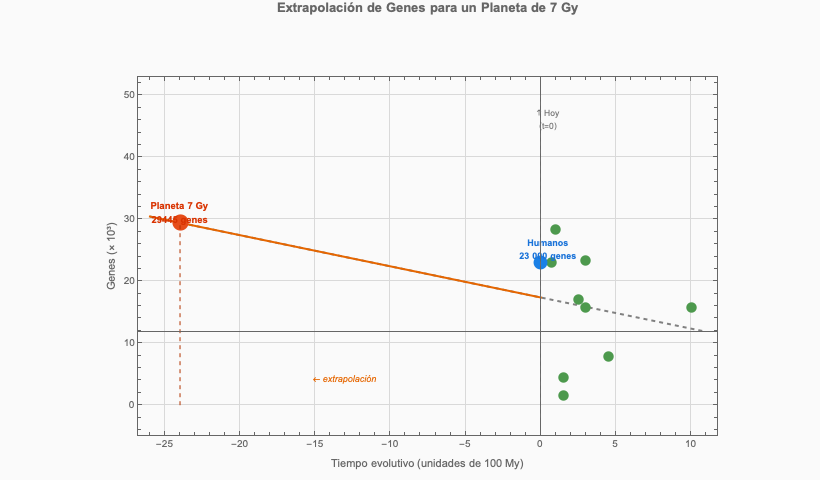

In [271]:
(* ─── GRÁFICA 3C: EXTRAPOLACIÓN VISUAL AL PLANETA DE 7 Gy ─── *)

(* Punto de predicción: t = -(24 unidades) = -24 en el eje x  *)
(* (más reciente/avanzado que los humanos)                    *)
tPred = -tiempoExtraUnidades;   (* -24 unidades *)
predGenesKpt = modeloGenes[tPred];
predNuclMpt  = modeloNucl[tPred];

(* Gráfica genes con extrapolación *)
xExtMin = -26; xExtMax = 11;

fitGenesExt = Plot[modeloGenes[x], {x, xExtMin, xExtMax},
  PlotStyle -> {Directive[GrayLevel[0.5], Thick, Dashed]},
  DisplayFunction -> Identity];
fitGenesExtra = Plot[modeloGenes[x], {x, xExtMin, 0.01},
  PlotStyle -> {Directive[RGBColor[0.9,0.4,0.0], Thick]},
  DisplayFunction -> Identity];

ptPred = Graphics[{
  {RGBColor[0.9,0.3,0.1], PointSize[0.028], Point[{tPred, predGenesKpt}]},
  {Dashed, RGBColor[0.7,0.2,0.0],
   Line[{{tPred, 0}, {tPred, predGenesKpt}}]},
  Text[Style["Planeta 7 Gy\n"<>ToString[Round[predGenesKpt*1000]]<>" genes",
             9.5, Bold, RGBColor[0.85,0.2,0.0]],
       {tPred, predGenesKpt + 1.5}],
  Text[Style["← extrapolación", 9, Italic, RGBColor[0.9,0.4,0.0]],
       {-13, 4}]
}];

ptHumano = Graphics[{
  {RGBColor[0.1,0.5,0.9], PointSize[0.024], Point[{tiempoX[[1]], genesK[[1]]}]},
  Text[Style["Humanos\n23 000 genes", 9, Bold, RGBColor[0.1,0.45,0.85]],
       {tiempoX[[1]]+0.5, genesK[[1]]+2.0}]
}];

Show[fitGenesExt, fitGenesExtra,
     ListPlot[Transpose[{tiempoX, genesK}],
       PlotStyle -> Directive[RGBColor[0.3,0.6,0.3], PointSize[0.018]]],
     ptPred, ptHumano,
  Frame       -> True,
  FrameLabel  -> {{Style["Genes (× 10³)", 11], None},
                  {Style["Tiempo evolutivo (unidades de 100 My)", 11], None}},
  PlotLabel   -> Style["Extrapolación de Genes para un Planeta de 7 Gy", Bold, 13],
  PlotRange   -> {{xExtMin, xExtMax}, {-2, 50}},
  GridLines   -> Automatic,
  GridLinesStyle -> Directive[LightGray, Thin],
  Epilog -> {Directive[Thin, GrayLevel[0.6], Dashed],
             Line[{{0, -2}, {0, 50}}],
             Text[Style["↑ Hoy\n(t=0)", 8.5, GrayLevel[0.45]], {0.5, 46}]},
  ImageSize   -> {820, 480},
  Background  -> GrayLevel[0.98],
  ImagePadding -> {{65, 30}, {45, 60}}]


---
## Resumen de Resultados

### Problema 1 — Porcentajes de tiempo con vida

| Categoría | Porcentaje |
|-----------|-----------|
| Vida de cualquier tipo | ~82.6 % |
| Solo vida bacteriana | ~43.5 % |
| Vida más compleja que bacterias | ~39.1 % |
| Formas similares a mamíferos | ~1.41 % |
| Humanos modernos | ~0.00109 % |

### Problema 2 — Sistemas biológicos más pequeños

- La relación $\log_{10}V$ vs $\log_{10}N$ es lineal con pendiente $\approx 1.86$, lo que indica $V \propto N^{1.86}$.
- Un organismo con **1 000 nucleótidos** sería clasificado como **no vivo** (cae en la región de virus no vivos).
- Un organismo con $V = 10^{12}\ \text{nm}^3$ tendría **~77 millones de nucleótidos** (similar a organismos vivos como E. coli avanzado).
- Caben aproximadamente **~2 370 bacteriófagos T4** en el volumen de una *E. coli*.

### Problema 3 — Evolución genómica

| Parámetro | Tasa de cambio |
|-----------|---------------|
| Genes | ~730 genes por 100 My |
| Nucleótidos | ~363 M nucleótidos por 100 My |

Para un planeta de **7 Gy** de edad:
- Genes estimados: **~40 500 genes**
- Nucleótidos estimados: **~12 000 millones (12 G nucleótidos)**
